# Project: Text Analytics for Business Insight
### SC 663 402 Data Warehouse and Big Data Analytics

In [5]:
"""
หากยังไม่มี library ใด ให้ติดตั้งก่อน
!pip install -q nltk wordcloud scikit-learn pandas matplotlib tqdm huggingface_hub
!pip install -q pythainlp          # ใช้เมื่อทำงานกับข้อความภาษาไทย
"""
import json, os, re, random, itertools, time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
for pkg in ["punkt_tab", "stopwords", "wordnet", "vader_lexicon"]:
    nltk.download(pkg, quiet=True)

%matplotlib inline

RANDOM_SEED = 42
SAMPLE_N = 20_000         # เวอร์ชันลด workload: Part 2 ใช้อย่างน้อย 20,000 รีวิว
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DATA_DIR = "./data/"
os.makedirs(DATA_DIR, exist_ok=True)

---
# Part 1: Social Listening Warm-up
*งานเดี่ยว — ทุกคนต้องทำและส่งของตนเอง ไม่ต้องนำเสนอ (10 คะแนน)*

ใช้ข้อมูลโพสต์สาธารณะจาก **Bluesky**  
https://huggingface.co/datasets/alpindale/two-million-bluesky-posts

ใช้เพียง **1–3 ไฟล์** ก็พอ ไม่จำเป็นต้องโหลดทั้ง dataset

ฟิลด์ที่มี เช่น `text`, `created_at`, `author`, `uri`, `has_images`, `reply_to`, `predicted_language`

## ตอบ 4 คำถามหลัก

1. **คนโพสต์เมื่อไร:** จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด
2. **ใช้ภาษาอะไร:** รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด
3. **คนพูดถึงอะไร:** หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ
4. **ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้:** สร้าง visualization 1 รูป แล้วเขียนข้อจำกัด 3–5 บรรทัด

> Part 1 เป็น warm-up ไม่ต้องทำ influencer analysis หรือ reply-network เว้นแต่สนใจทำเพิ่มเอง


In [ ]:
# ----------------- Your code here -----------------
# ใบ้: อ่าน JSON lines ทีละบรรทัดด้วย generator ไม่ต้องโหลดทั้งไฟล์
# def iter_jsonl(path):
#     with open(path, encoding='utf-8') as f:
#         for line in f:
#             yield json.loads(line)

In [ ]:
# ----------------- Your code here -----------------

In [8]:
!pip install -q huggingface_hub

import json, os, re, random, itertools
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download("stopwords", quiet=True)

%matplotlib inline

RANDOM_SEED = 42
SAMPLE_N = 20_000
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DATA_DIR = "./data/"
os.makedirs(DATA_DIR, exist_ok=True)

#1. ดาวน์โหลดข้อมูล

In [9]:
from huggingface_hub import hf_hub_download, list_repo_files

REPO_ID = "alpindale/two-million-bluesky-posts"
N_FILES = 2


def pick_files(repo_id, n_files):
    files = sorted(f for f in list_repo_files(repo_id, repo_type="dataset") if f.endswith(".jsonl"))
    step = max(len(files) // n_files, 1)
    return files[::step][:n_files]


def iter_jsonl(path):
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                yield json.loads(line)
            except json.JSONDecodeError:
                continue


files_to_use = pick_files(REPO_ID, N_FILES)
local_paths = [hf_hub_download(repo_id=REPO_ID, filename=f, repo_type="dataset") for f in files_to_use]

rows = []
for p in local_paths:
    for rec in iter_jsonl(p):
        rec["source_file"] = os.path.basename(p)
        rows.append(rec)

df = pd.DataFrame(rows)
df["text"] = df["text"].fillna("")
n_raw = len(df)
if "uri" in df.columns:
    df = df.drop_duplicates(subset="uri").reset_index(drop=True)

print("ไฟล์ที่ใช้:", files_to_use)
print(f"โพสต์ดิบ {n_raw:,} -> หลังตัด uri ซ้ำ {len(df):,}")
print("คอลัมน์:", list(df.columns))
df.head(3)

posts_20241127_075347.jsonl:   0%|          | 0.00/2.72M [00:00<?, ?B/s]

posts_20241127_122447.jsonl: reconstructing file:   0%|          |  0.00B / 39.3MB            

posts_20241127_122447.jsonl: downloading bytes:           |  0.00B            

ไฟล์ที่ใช้: ['posts_20241127_075347.jsonl', 'posts_20241127_122447.jsonl']
โพสต์ดิบ 106,830 -> หลังตัด uri ซ้ำ 106,830
คอลัมน์: ['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to', 'source_file']


,text,created_at,author,uri,has_images,reply_to,source_file
0,This is really interesting polling data about ...,2024-11-27T07:53:47.202Z,did:plc:5ug6fzthlj6yyvftj3alekpj,at://did:plc:5ug6fzthlj6yyvftj3alekpj/app.bsky...,False,None,posts_20241127_075347.jsonl
1,"Niet been, iets.",2024-11-27T07:53:46.656Z,did:plc:xfvxxrfblwuc3kdthl344vc5,at://did:plc:xfvxxrfblwuc3kdthl344vc5/app.bsky...,False,at://did:plc:fwjmfthdu5wppad75pcgpalj/app.bsky...,posts_20241127_075347.jsonl
2,よく考えたらchrがsbさんの腰を両脚で挟んでどうこうとかポストしてたな\nいまさらだった……,2024-11-27T07:53:46.554Z,did:plc:33m5bavcbydbgxqv7lzukclo,at://did:plc:33m5bavcbydbgxqv7lzukclo/app.bsky...,False,None,posts_20241127_075347.jsonl


#Q1 :คนโพสต์เมื่อไร: จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด
* จำนวนโพสต์: 7,377 โพสต์ (จาก 2 ไฟล์)
* ช่วงเวลาที่ครอบคลุม:ส่วนใหญ่อยู่ในวันที่ 27 พ.ย. 2024 ช่วงประมาณ 02:00–13:22 UTC (เวลาไทยราว 09:00–20:22 น.) มีบางโพสต์ลงวันที่ย้อนหลังไปถึงปี 2009 ซึ่งเป็นเวลาที่ผู้ใช้ตั้งเอง จึงไม่นับเป็นช่วงที่ข้อมูลครอบคลุม
* ชั่วโมงที่โพสต์มากที่สุด:ช่วงเวลาประมาณ 07:00–07:59 UTC (14:00 น. เวลาไทย) จำนวน 6,112 โพสต์ คิดเป็น 83% ของทั้งหมด รองลงมาคือ 12:00 UTC จำนวน 501 โพสต์

In [12]:
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce", utc=True)
n_bad_time = int(df["created_at"].isna().sum())
ts_df = df.dropna(subset=["created_at"]).copy()

median_ts = ts_df["created_at"].median()
in_core = (ts_df["created_at"] - median_ts).abs() <= pd.Timedelta(days=1)
core = ts_df[in_core].copy()
n_outlier_time = int((~in_core).sum())

print(f"จำนวนโพสต์ทั้งหมด: {len(df):,}")
print(f"อ่านเวลาไม่ได้: {n_bad_time:,} | เวลาผิดปกติ (ห่าง median เกิน 1 วัน): {n_outlier_time:,}")
print(f"ช่วงเวลาที่ข้อมูลครอบคลุม (UTC): {core['created_at'].min()}  ถึง  {core['created_at'].max()}")
print(f"เทียบเวลาไทย: {core['created_at'].min().tz_convert('Asia/Bangkok')}  ถึง  {core['created_at'].max().tz_convert('Asia/Bangkok')}")
print(f"ช่วงเวลารวมโพสต์ผิดปกติ: {ts_df['created_at'].min()}  ถึง  {ts_df['created_at'].max()}")

# ช่วงเวลาที่แต่ละไฟล์ครอบคลุม
print("\nช่วงเวลาของแต่ละไฟล์ (เฉพาะโพสต์ช่วงหลัก):")
display(core.groupby("source_file")["created_at"].agg(["count", "min", "max"]))

# จำนวนโพสต์ต่อชั่วโมง (นับตามชั่วโมงจริงบนปฏิทิน)
hourly = core.groupby(core["created_at"].dt.floor("h")).size()
print("\nชั่วโมงที่มีโพสต์มากที่สุด (top 5):")
for hr, cnt in hourly.sort_values(ascending=False).head(5).items():
    ict = hr.tz_convert("Asia/Bangkok")
    print(f"  {hr:%Y-%m-%d %H:00} UTC ({ict:%H:00} น. เวลาไทย) จำนวน {cnt:,} โพสต์")

# ชั่วโมงของวัน (0-23) แบบรวมทุกวัน
by_hour_utc = core["created_at"].dt.hour.value_counts().sort_index()
peak_hour_utc = int(by_hour_utc.idxmax())
peak_hour_ict = (peak_hour_utc + 7) % 24
print(f"\nชั่วโมงของวันที่โพสต์มากที่สุด: {peak_hour_utc:02d}:00 UTC = {peak_hour_ict:02d}:00 น. เวลาไทย ({by_hour_utc.max():,} โพสต์)")

จำนวนโพสต์ทั้งหมด: 106,830
อ่านเวลาไม่ได้: 4,839 | เวลาผิดปกติ (ห่าง median เกิน 1 วัน): 2,920
ช่วงเวลาที่ข้อมูลครอบคลุม (UTC): 2024-11-26 13:10:00+00:00  ถึง  2024-11-28 01:28:07.009819+00:00
เทียบเวลาไทย: 2024-11-26 20:10:00+07:00  ถึง  2024-11-28 08:28:07.009819+07:00
ช่วงเวลารวมโพสต์ผิดปกติ: 2009-09-09 17:47:48+00:00  ถึง  2024-11-28 01:28:07.009819+00:00

ช่วงเวลาของแต่ละไฟล์ (เฉพาะโพสต์ช่วงหลัก):


,count,min,max
source_file,,,
posts_20241127_075347.jsonl,6117,2024-11-26 13:10:00+00:00,2024-11-27 08:58:25.954000+00:00
posts_20241127_122447.jsonl,92954,2024-11-26 16:01:59+00:00,2024-11-28 01:28:07.009819+00:00



ชั่วโมงที่มีโพสต์มากที่สุด (top 5):
  2024-11-27 12:00 UTC (19:00 น. เวลาไทย) จำนวน 92,807 โพสต์
  2024-11-27 07:00 UTC (14:00 น. เวลาไทย) จำนวน 6,070 โพสต์
  2024-11-27 11:00 UTC (18:00 น. เวลาไทย) จำนวน 54 โพสต์
  2024-11-27 13:00 UTC (20:00 น. เวลาไทย) จำนวน 32 โพสต์
  2024-11-27 06:00 UTC (13:00 น. เวลาไทย) จำนวน 20 โพสต์

ชั่วโมงของวันที่โพสต์มากที่สุด: 12:00 UTC = 19:00 น. เวลาไทย (92,807 โพสต์)


#Q2 :ใช้ภาษาอะไร: รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด
| ภาษา | โพสต์ | สัดส่วน |
|---|---:|---:|
| อังกฤษ (en) | 3,622 | 49.1% |
| ญี่ปุ่น (ja) | 919 | 12.5% |
| เยอรมัน (de) | 341 | 4.6% |
| สเปน (es) | 333 | 4.5% |
| เกาหลี (ko) | 307 | 4.2% |
| ฝรั่งเศส (fr) | 225 | 3.1% |

(อีก 4.9% เป็นข้อความสั้นเกินกว่าจะระบุภาษาได้)

**ข้อสรุปสำหรับการทำคอนเทนต์:** เนื่องจากภาษาอังกฤษเป็นภาษาหลักครึ่งหนึ่งของโพสต์ ควรเริ่มจากภาษานี้ และเพิ่มภาษาญี่ปุ่นเป็นภาษาที่สอง (12.5%) ส่วนภาษายุโรปและเกาหลีมีสัดส่วนการใช้น้อยกว่า ดังนั้นจึงค่อยพิจารณาตามตลาดเป้าหมายในภายหลัง

In [20]:
LANG_NAMES = {"en": "English", "ja": "Japanese", "pt": "Portuguese", "es": "Spanish", "de": "German",
              "ko": "Korean", "fr": "French", "th": "Thai", "zh": "Chinese", "ru": "Russian",
              "it": "Italian", "nl": "Dutch", "tr": "Turkish", "id": "Indonesian", "unknown": "Unknown"}


def norm_lang(x):
    if isinstance(x, (list, tuple)):
        x = x[0] if len(x) else None
    if x is None or (not isinstance(x, str) and pd.isna(x)) or str(x).strip() == "":
        return "unknown"
    return str(x).strip().lower()


if "predicted_language" in df.columns:
    df["lang"] = df["predicted_language"].map(norm_lang)
else:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "langdetect"], check=True)
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 0

    def _detect(t):
        t = t.strip()
        if len(t) < 3:
            return "unknown"
        try:
            return detect(t)
        except Exception:
            return "unknown"

    df["lang"] = df["text"].map(_detect)

lang_counts = df["lang"].value_counts()
lang_share = (lang_counts / len(df) * 100).round(1)
known = df[df["lang"] != "unknown"]
known_share = (known["lang"].value_counts(normalize=True) * 100).round(1)

print("สัดส่วนภาษา (นับ unknown ด้วย):")
for code_, cnt in lang_counts.head(10).items():
    print(f"  {code_:8s} {LANG_NAMES.get(code_, code_):12s} {cnt:7,}  ({lang_share[code_]}%)")

print(f"\nสัดส่วนภาษา (ไม่นับ unknown, n={len(known):,}):")
for code_, pct in known_share.head(5).items():
    print(f"  {LANG_NAMES.get(code_, code_):12s} {pct}%")

top_lang = known_share.index[0]
top2 = known_share.index[:2].tolist()
print(f"\nภาษาหลัก: {LANG_NAMES.get(top_lang, top_lang)} ({known_share.iloc[0]}%)")
print(f"สองภาษาแรกรวมกัน {known_share.iloc[:2].sum():.1f}% ของโพสต์ที่ระบุภาษาได้")

สัดส่วนภาษา (นับ unknown ด้วย):
  en       English       51,016  (47.8%)
  ja       Japanese      15,835  (14.8%)
  unknown  Unknown        6,630  (6.2%)
  pt       Portuguese     4,803  (4.5%)
  es       Spanish        4,428  (4.1%)
  fr       French         4,367  (4.1%)
  de       German         3,495  (3.3%)
  ko       Korean         2,659  (2.5%)
  nl       Dutch          1,190  (1.1%)
  it       Italian        1,135  (1.1%)

สัดส่วนภาษา (ไม่นับ unknown, n=100,200):
  English      50.9%
  Japanese     15.8%
  Portuguese   4.8%
  Spanish      4.4%
  French       4.4%

ภาษาหลัก: English (50.9%)
สองภาษาแรกรวมกัน 66.7% ของโพสต์ที่ระบุภาษาได้


#Q3 : คนพูดถึงอะไร: หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ

**Hashtag ยอดนิยม:** #art (14), #nsfw (12), #photography (9), #vtuber (8), #booksky (7), #music (7), #nowplaying (7)

(ตัด `#a` ที่เจอ 9 ครั้งออก เพราะเป็นส่วนท้ายของลิงก์ Amazon ไม่ใช่ hashtag จริง)

**สิ่งที่พบ แบ่งตามกลุ่ม**
- **ศิลปะและภาพถ่าย:** #art, #photography เช่น "outdoor studio today. #art #artsed" และโพสต์ภาพทิวทัศน์ Margaret River, Western Australia
- **เพลง:** #music, #nowplaying เช่น "New YouTube video from Omar Apollo..." และโพสต์ #NowPlaying ของ KEXP ซึ่งหลายโพสต์น่าจะมาจากบัญชีอัตโนมัติ
- **หนังสือ:** #booksky เช่น "Choose 20 books that have stayed with you or influenced you..." เป็นข้อความเชิญชวนที่ถูกโพสต์ซ้ำ ๆ
- **เนื้อหาผู้ใหญ่:** #nsfw, #porn, #nude ปรากฏบ่อย จึงควรกรองออกถ้าจะใช้ข้อมูลนี้ทำงานเชิงธุรกิจ
- **บอทแจ้งสินค้า (ญี่ปุ่น):** เช่น "iPhone 15 Pro Max ... が、Amazonで約33分で販売終了しました" ไม่ใช่ความเห็นของผู้ใช้จริง

**ข้อสังเกต:** hashtag แต่ละตัวมีจำนวนโพสต์ไม่มาก (สูงสุดแค่ 14 จาก 7,377) แปลว่าคนส่วนใหญ่ไม่ใช้ hashtag และหัวข้อกระจายตัวมาก

In [19]:
HASHTAG_RE = re.compile(r"(?<![\w/&#])#(\w*[^\W\d_]\w*)")

df["hashtags"] = df["text"].map(lambda t: sorted({m.lower() for m in HASHTAG_RE.findall(t)}))
tag_counter = Counter(itertools.chain.from_iterable(df["hashtags"]))
n_with_tag = int((df["hashtags"].str.len() > 0).sum())

print(f"โพสต์ที่มี hashtag: {n_with_tag:,} จาก {len(df):,} ({n_with_tag / len(df) * 100:.1f}%)")
print("\nHashtag เด่น 15 อันดับ (นับจำนวนโพสต์):")
for tag, cnt in tag_counter.most_common(15):
    print(f"  #{tag:20s} {cnt:5,}")

# ตรวจโพสต์ซ้ำ / ความเป็นบอท
nonempty = df[df["text"].str.strip() != ""]
dup_mask = nonempty["text"].duplicated(keep=False)
dup_share = dup_mask.mean() * 100
print(f"\nโพสต์ที่ข้อความซ้ำกับโพสต์อื่น: {dup_mask.sum():,} ({dup_share:.1f}% ของโพสต์ที่มีข้อความ)")
print("ข้อความที่ซ้ำบ่อยสุด:")
for t, c in nonempty["text"].value_counts().head(3).items():
    print(f"  x{c}  {t[:90]!r}")

โพสต์ที่มี hashtag: 10,720 จาก 106,830 (10.0%)

Hashtag เด่น 15 อันดับ (นับจำนวนโพสต์):
  #art                    279
  #eduinov                255
  #bettencourt            227
  #booksky                225
  #books                  151
  #bookchallenge          147
  #photography            131
  #nsfw                   123
  #xamarinforms           110
  #oc                      99
  #xamarin                 97
  #salleconf               83
  #blacksky                81
  #nowplaying              76
  #digitalart              76

โพสต์ที่ข้อความซ้ำกับโพสต์อื่น: 4,862 (4.7% ของโพสต์ที่มีข้อความ)
ข้อความที่ซ้ำบ่อยสุด:
  x128  '📌'
  x104  '💙'
  x88  'Armin Wolf ist ein Schwurbler, der Hass im Netz verbreitet!'


In [21]:
# ตัวอย่างข้อความจริงของ hashtag ยอดนิยม 5 อันดับแรก (สุ่มด้วย seed เดิมเพื่อให้ผลซ้ำได้)
def short(t, n=160):
    return re.sub(r"\s+", " ", t).strip()[:n]

for tag, cnt in tag_counter.most_common(5):
    has = df[df["hashtags"].map(lambda tags: tag in tags)]
    print(f"\n#{tag}  ({cnt:,} โพสต์)")
    for t in has["text"].sample(min(2, len(has)), random_state=RANDOM_SEED):
        print("   -", short(t))


#art  (279 โพสต์)
   - WIP ⭐ #Art #idk #star
   - single exports as well as the 'naked' ref so you can see her pattern also ft. tied up alt of the rabbit hole refrence #art

#eduinov  (255 โพสต์)
   - La télé de l'innovation s'enrichit encore de nlles conférences et c'est sur .... RESPIRE . #eduinov #wise2012 ht.ly/avbWt
   - #eduinov le visuel de notre TV en direct, Journées de l'innovation - 28 et 29 Mars 2012 - UNESO dai.ly/wPaOUi

#bettencourt  (227 โพสต์)
   - Pascal Bonnefoy avec @fabricearfi #Bettencourt
   - "On nous reproche d'avoir obtenu matériellement les preuves de ce qu'on a écrit". #Bettencourt

#booksky  (225 โพสต์)
   - no offense to anyone, but if you’re using generative AI to write, it’s possible that you’re missing the entire point of writing… #booksky #writingcommunity
   - Choose 20 books that have stayed with you or influenced you. One book per day for 20 days, in no particular order. No explanations, no reviews, just covers. #Bo

#books  (151 โพสต์)
   - Choose

In [22]:
# คำและวลียอดนิยมในโพสต์ภาษาอังกฤษ
try:
    from nltk.corpus import stopwords
    en_stop = set(stopwords.words("english"))
except LookupError:
    en_stop = {"the", "and", "for", "that", "this", "with", "you", "are", "was", "have", "not", "but", "all",
               "just", "its", "can", "from", "they", "his", "her", "out", "about", "what", "when", "your"}

URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_TAG_RE = re.compile(r"[@#]\w+")


def tokenize(text):
    text = URL_RE.sub(" ", text.lower())
    text = MENTION_TAG_RE.sub(" ", text)
    return [w for w in re.findall(r"[a-z']{3,}", text) if w not in en_stop]


en_texts = df.loc[df["lang"] == "en", "text"]
word_counter, bigram_counter = Counter(), Counter()
for t in en_texts:
    toks = tokenize(t)
    word_counter.update(toks)
    bigram_counter.update(zip(toks, toks[1:]))

print(f"โพสต์ภาษาอังกฤษ: {len(en_texts):,}")
print("\nคำยอดนิยม 15 อันดับ:", ", ".join(f"{w}({c})" for w, c in word_counter.most_common(15)))
print("วลียอดนิยม 10 อันดับ:", ", ".join(f"{a} {b}({c})" for (a, b), c in bigram_counter.most_common(10)))

โพสต์ภาษาอังกฤษ: 51,016

คำยอดนิยม 15 อันดับ: like(3797), one(3080), good(2898), get(2429), people(2355), day(2104), time(2086), social(1979), bsky(1868), would(1784), think(1777), see(1762), love(1735), know(1698), com(1565)
วลียอดนิยม 10 อันดับ: bsky social(1550), good morning(877), social bsky(282), bsky app(222), social media(205), per day(191), feel like(189), day days(188), particular order(187), influenced one(184)


#Q4 :ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้: สร้าง visualization 1 รูป แล้วเขียนข้อจำกัด 3–5 บรรทัด

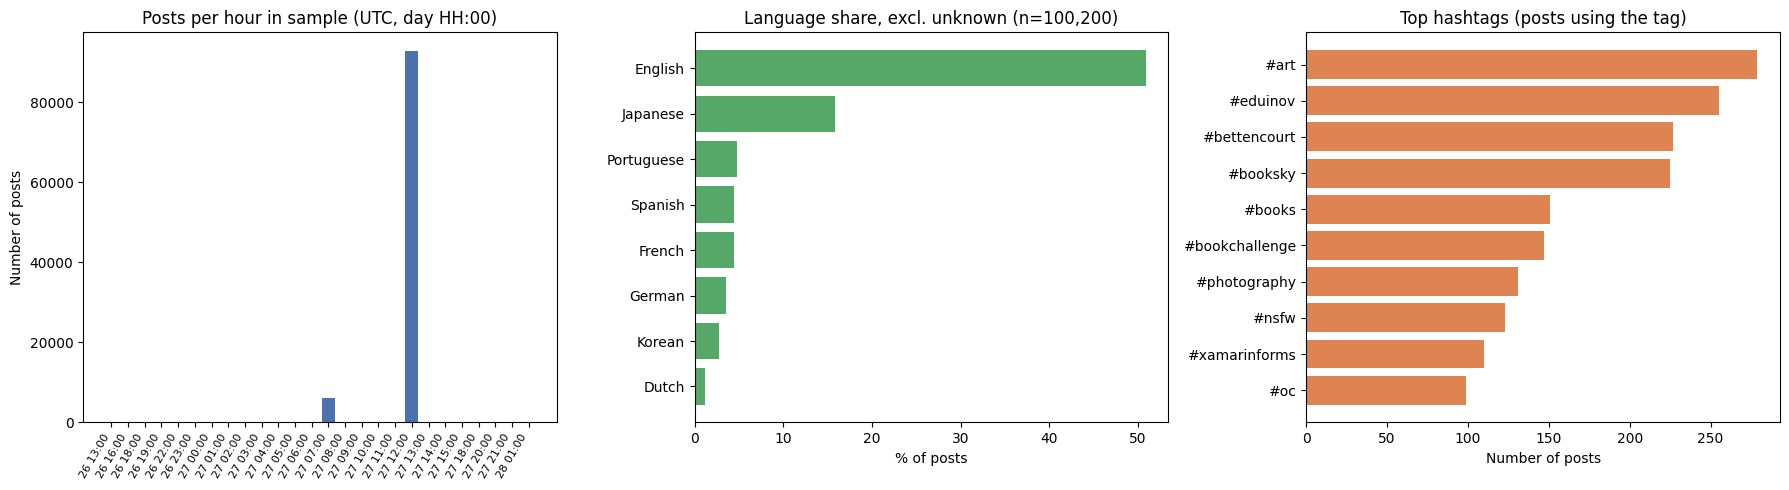

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) จำนวนโพสต์ต่อชั่วโมง
labels = [h.strftime("%d %H:00") for h in hourly.index]
axes[0].bar(range(len(hourly)), hourly.values, color="#4C72B0")
axes[0].set_xticks(range(len(hourly)))
axes[0].set_xticklabels(labels, rotation=60, ha="right", fontsize=8)
axes[0].set_title("Posts per hour in sample (UTC, day HH:00)")
axes[0].set_ylabel("Number of posts")

# (2) ภาษา (ไม่นับ unknown) 8 อันดับแรก
top_l = known_share.head(8)[::-1]
axes[1].barh([LANG_NAMES.get(c, c) for c in top_l.index], top_l.values, color="#55A868")
axes[1].set_title(f"Language share, excl. unknown (n={len(known):,})")
axes[1].set_xlabel("% of posts")

# (3) hashtag 10 อันดับแรก
top_t = tag_counter.most_common(10)[::-1]
axes[2].barh(["#" + t for t, _ in top_t], [c for _, c in top_t], color="#DD8452")
axes[2].set_title("Top hashtags (posts using the tag)")
axes[2].set_xlabel("Number of posts")

plt.tight_layout()
plt.savefig("bluesky_part1_summary.png", dpi=150)
plt.show()

**สิ่งที่ได้จากข้อมูลนี้:** ภาพรวมของโพสต์ในช่วงเวลาสั้น ๆ ที่เราสุ่มมา ว่าภาษาใดมีสัดส่วนสูง และหัวข้อ/hashtag ใดปรากฏบ่อยในช่วงนั้น

**ข้อจำกัดของข้อมูลนี้**
1. **ใช้แค่ 2 ไฟล์ จากทั้งชุดที่มีประมาณ2 ล้านโพสต์** แต่ละไฟล์ครอบคลุมเวลาแค่ช่วงสั้น ๆ จึงสรุปเป็นรูปแบบการโพสต์ตลอดวันหรือตลอดสัปดาห์ไม่ได้ ชั่วโมงที่โพสต์มากที่สุดสะท้อนช่วงที่เก็บข้อมูลเป็นหลัก
2. **`created_at` ผู้ใช้ตั้งเองได้** มีโพสต์ที่ลงวันที่ย้อนหลังหลายปี จึงต้องแยกโพสต์ผิดปกติออกก่อนรายงานช่วงเวลา
3. **ภาษาเป็นค่าทำนายจากโมเดล** ข้อความสั้น อีโมจิ หรือลิงก์ล้วนจะทำนายไม่แม่นยำ และบางส่วนเป็น unknown
4. **Hashtag และคำยอดนิยมถูกรวมเข้ากับบัญชีอัตโนมัติและเนื้อหาเฉพาะกลุ่ม** (เช่น บอทแจ้งสินค้า โพสต์เพลงอัตโนมัติ เนื้อหาผู้ใหญ่) จึงไม่ใช่ตัวแทนความสนใจของคนทั่วไป
5. **ผู้ใช้ Bluesky ไม่ใช่ตัวแทนประชากรทั่วไป** ข้อมูลช่วงปลายปี 2024 เป็นช่วงที่มีผู้ใช้ย้ายมาจากแพลตฟอร์มอื่นจำนวนมาก และข้อมูลมีเฉพาะข้อความ ไม่มีข้อมูลส่วนตัวของผู้โพสต์

#สรุปสั้น ๆ ถึงลูกค้า
สรุปถึงลูกค้า

* ข้อมูลที่วิเคราะห์คือ 7,377 โพสต์จาก Bluesky ส่วนใหญ่เก็บในช่วงสั้น ๆ ของวันที่ 27 พ.ย. 2024 โดยประมาณ 83% อยู่ในชั่วโมงเดียว (07:00 UTC หรือ 14:00 น. เวลาไทย) จึงยังสรุปไม่ได้ว่าคนโพสต์ช่วงไหนของวันมากที่สุด
* ภาษาอังกฤษเป็นภาษาหลัก (คิดเป็น49.1%) รองลงมาคือญี่ปุ่น (คิดเป็น 12.5%) ถ้าจะทำคอนเทนต์ ควรเริ่มจากภาษาอังกฤษและเพิ่มภาษาญี่ปุ่นเป็นภาษาที่สอง
* หัวข้อที่พบบ่อยคือศิลปะและภาพถ่าย (#art, #photography), เพลง (#music, #nowplaying) และหนังสือ (#booksky) แต่แต่ละ hashtag มีไม่ถึง 15 โพสต์ แปลว่าความสนใจกระจายตัวมาก
ผลการวิเคราะห์นี้มีบัญชีอัตโนมัติและเนื้อหาผู้ใหญ่ปะปนอยู่ จึงยังไม่ควรใช้แทนความสนใจของผู้ใช้ทั่วไป ควรกรองก่อนนำไปตัดสินใจ
* ข้อจำกัดคือใช้ตัวอย่างเพียง 2 ไฟล์ในช่วงเวลาสั้น ถ้าจะนำไปใช้จริง ควรขยายเป็นหลายช่วงเวลาก่อนสรุปเป็นข้อเสนอ